## Exploratory Data Analysis

In [1]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# loading data 
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## Filter for US Data Analyst roles.

In [2]:
df_DA_US  = df[(df['job_country']== 'United States') & (df['job_title_short'] == 'Data Analyst')]

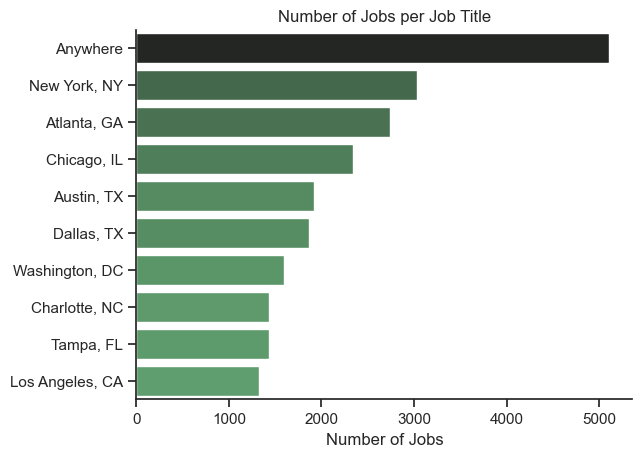

In [ ]:
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot,x='count',y='job_location',hue = 'count',palette='dark:g_r', legend = False)
sns.despine()
plt.title('Counts of Job Locations for Data analyst in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

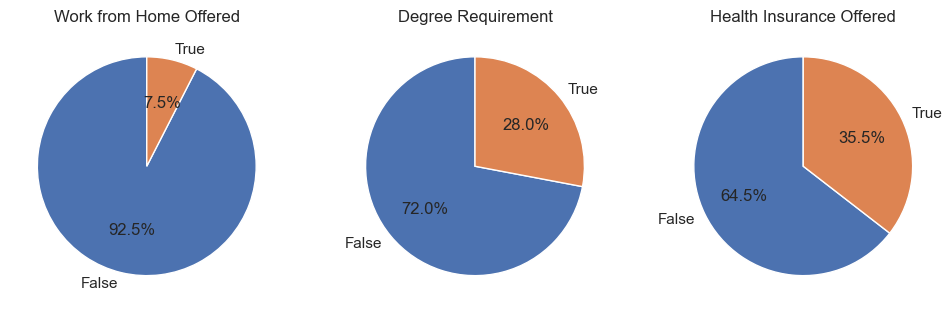

In [11]:
dict_column = {
    'job_work_from_home':'Work from Home Offered',
    'job_no_degree_mention':'Degree Requirement',
    'job_health_insurance':'Health Insurance Offered'
}

fig, ax = plt.subplots(1,3)
fig.set_size_inches((12,5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_US[column].value_counts(), labels=['False','True'],autopct='%1.1f%%',startangle = 90)
    ax[i].set_title(title)

plt.show()


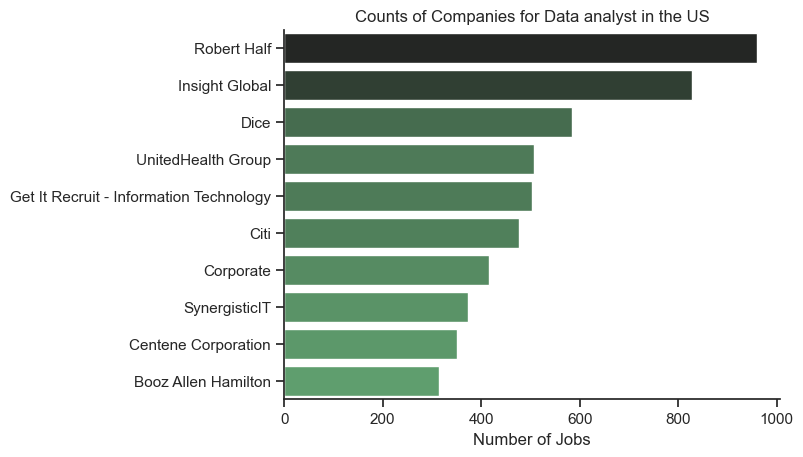

In [12]:
df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot,x='count',y='company_name',hue = 'count',palette='dark:g_r', legend = False)
sns.despine()
plt.title('Counts of Companies for Data analyst in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()